# Notebook 9 — Survival Analysis & Hawkes Process

## Survival Analysis
Frames rare events as a time-to-event problem:
> "Which driving conditions predict *earlier* occurrence of a near-miss?"

Methods:
- **Kaplan-Meier** — non-parametric survival curve
- **Log-rank test** — compare survival by group (urban vs. highway)
- **Cox Proportional Hazards** — hazard ratios for each covariate

## Hawkes Process
Models the *self-exciting* clustering of safety events:
> "After a near-miss, the rate of subsequent events spikes then decays."

Parameters:
- μ = background (exogenous) event rate
- α/β = branching ratio — fraction of events caused by prior events
- β = decay rate (how quickly excitation fades)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.plotting import plot_lifetimes

from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances
from src.rare_events.rare_event_detector import run_all_detectors
from src.survival.survival_analysis import (
    build_survival_dataset, kaplan_meier, compare_survival_curves,
    cox_proportional_hazards, competing_risks_incidence
)
from src.point_processes.hawkes_process import (
    fit_hawkes, fit_hawkes_by_group, simulate_hawkes,
    intensity_series, time_rescaling_test, HawkesParams
)

sns.set_theme(style='whitegrid')

In [2]:
dataset = load_dataset('../data', max_segments=8)
trajectories = extract_trajectories(dataset['lidar_box'])
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)
events_df = run_all_detectors(trajectories, ttc_df=ttc_df)

print(f'Total events detected: {len(events_df)}')
if not events_df.empty:
    print(events_df['event_type'].value_counts())

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: invalid value encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: divide by zero encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)


Total events detected: 81
event_type
sudden_swerve              63
near_miss                   9
pedestrian_encroachment     7
hard_braking                2
Name: count, dtype: int64


## Kaplan-Meier Survival Curve

In [3]:
survival_df = build_survival_dataset(
    trajectories, events_df,
    event_type='hard_braking',
    covariates=['mean_speed', 'mean_nearest_dist', 'mean_acceleration'],
)
print(f'Survival dataset: {len(survival_df)} tracks')
print(f'Events observed: {survival_df["event_observed"].sum()}')
survival_df.head()

Survival dataset: 898 tracks
Events observed: 169


,segment_id,object_id,duration,event_observed,mean_speed,mean_acceleration
0,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,6.004279,0,1.804627e-02,2.297689e-02
1,10203656353524179475_7625_000_7645_000,-I40EKAJnCM32Xu7_1l2GA,9.705082,0,4.215098e-13,4.477842e-14
2,10203656353524179475_7625_000_7645_000,-KpKb_7UDmsdQCf8FS3g9w,19.596968,0,1.821724e+01,1.103509e+00
3,10203656353524179475_7625_000_7645_000,-poM1mmL-pEZ10MmQvYahg,8.400906,0,4.074766e-02,3.518401e-02
4,10203656353524179475_7625_000_7645_000,1WP4TupVFubSnRO5xzftMw,2.297118,0,2.055531e-02,1.454182e-02


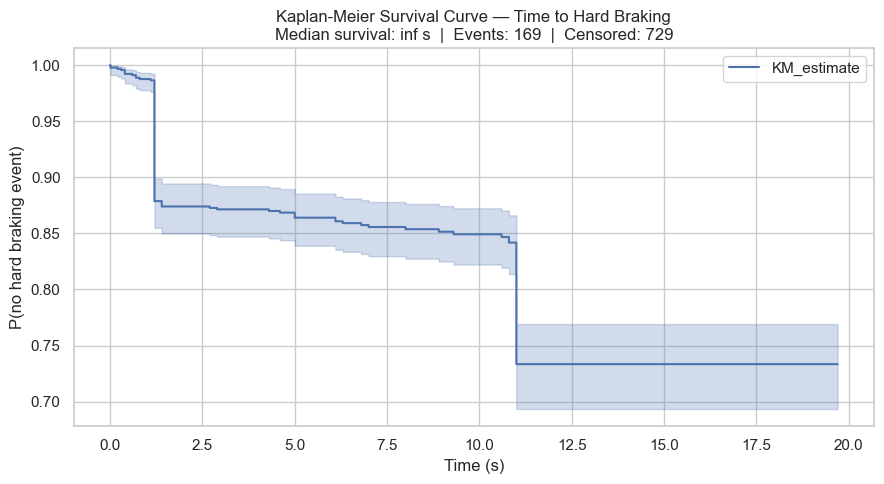

In [4]:
km = kaplan_meier(survival_df)

fig, ax = plt.subplots(figsize=(9, 5))
kmf = KaplanMeierFitter()
kmf.fit(survival_df['duration'], survival_df['event_observed'])
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel('Time (s)')
ax.set_ylabel('P(no hard braking event)')
ax.set_title(f'Kaplan-Meier Survival Curve — Time to Hard Braking\n'
             f'Median survival: {km.median_survival:.1f} s  |  '
             f'Events: {km.n_events}  |  Censored: {km.n_censored}')
plt.tight_layout()
plt.show()

## Cox Proportional Hazards Model

In [5]:
cox = cox_proportional_hazards(survival_df, covariates=['mean_speed', 'mean_nearest_dist', 'mean_acceleration'])
print(f'C-index (concordance): {cox.concordance:.4f}  (0.5 = random, 1.0 = perfect)')
print(f'AIC: {cox.aic:.2f}')
print(f'Events: {cox.n_events}')
print('\nHazard Ratios:')
print(cox.summary.to_string(index=False))
print('\nHR > 1 → covariate increases risk of hard braking event')

C-index (concordance): 0.5882  (0.5 = random, 1.0 = perfect)
AIC: 2162.94
Events: 169

Hazard Ratios:
        covariate  hazard_ratio  hr_lower_95  hr_upper_95  p_value  significant
       mean_speed      0.980902     0.940301     1.023257 0.371307        False
mean_acceleration      1.591676     0.962120     2.633178 0.070355        False

HR > 1 → covariate increases risk of hard braking event


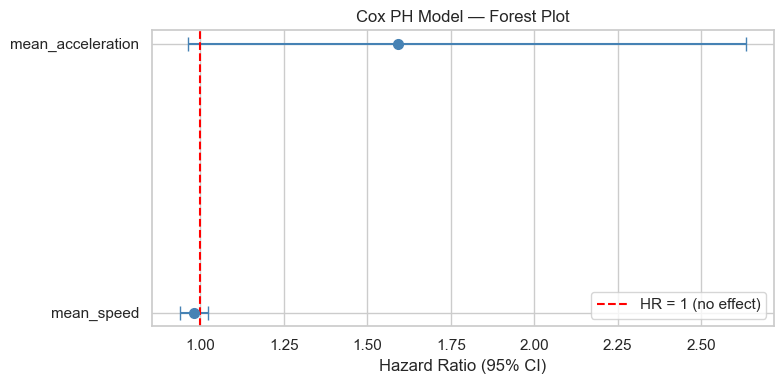

In [6]:
# Forest plot of hazard ratios
cox_s = cox.summary.dropna(subset=['hazard_ratio'])
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(cox_s))
ax.errorbar(
    cox_s['hazard_ratio'], y,
    xerr=[
        cox_s['hazard_ratio'] - cox_s['hr_lower_95'],
        cox_s['hr_upper_95'] - cox_s['hazard_ratio'],
    ],
    fmt='o', color='steelblue', capsize=5, markersize=7,
)
ax.axvline(1.0, color='red', linestyle='--', label='HR = 1 (no effect)')
ax.set_yticks(y)
ax.set_yticklabels(cox_s['covariate'])
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Cox PH Model — Forest Plot')
ax.legend()
plt.tight_layout()
plt.show()

## Hawkes Process — Rare-Event Self-Excitation

In [7]:
if events_df.empty:
    print('No events detected — simulating a Hawkes process for demonstration.')
    demo_params = HawkesParams(mu=0.05, alpha=0.4, beta=0.8)
    event_times = simulate_hawkes(demo_params, T=300.0, seed=42)
    print(f'Simulated {len(event_times)} events over 300 s')
else:
    event_times = events_df['timestamp_s'].sort_values().values
    print(f'Using {len(event_times)} real events')

Using 81 real events


In [8]:
params, log_lik = fit_hawkes(event_times, n_restarts=15)
print(params)
print(f'Log-likelihood: {log_lik:.4f}')

ks_stat, ks_p = time_rescaling_test(event_times, params)
print(f'\nGoodness of fit (time-rescaling KS test):')
print(f'  KS statistic: {ks_stat:.4f}')
print(f'  p-value: {ks_p:.4f}  {"✓ good fit" if ks_p > 0.05 else "✗ poor fit"}')

HawkesParams(μ=0.0000, α=0.2999, β=0.3223) | branching=0.9304 | stationary=True
Log-likelihood: -280.3483



Goodness of fit (time-rescaling KS test):
  KS statistic: 0.1968
  p-value: 0.0070  ✗ poor fit


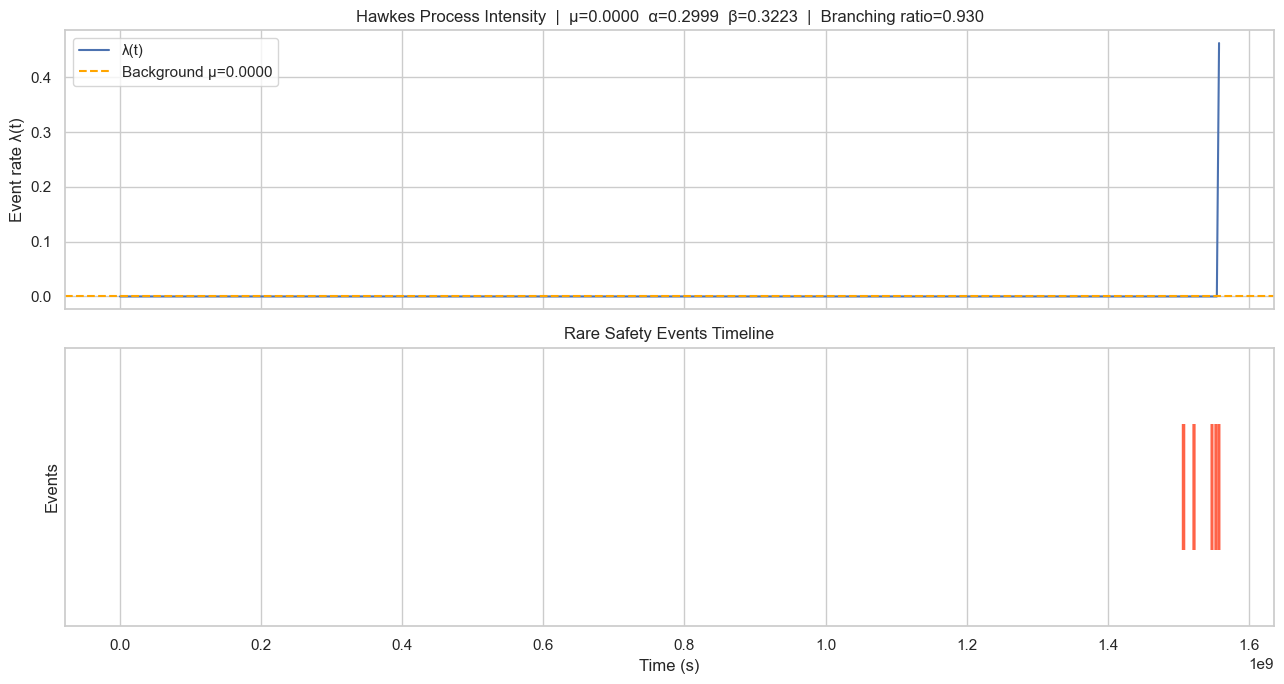


Interpretation:
  Branching ratio 0.930: 93.0% of events are triggered by prior events
  Unconditional event rate: 0.0000 events/s
  Is stationary (branching < 1): True


In [9]:
# Visualise intensity over time
T_obs = float(event_times.max())
t_grid = np.linspace(0, T_obs, 500)
lam = intensity_series(t_grid, event_times, params)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_grid, lam, 'b-', lw=1.5, label='λ(t)')
axes[0].axhline(params.mu, color='orange', linestyle='--', lw=1.5, label=f'Background μ={params.mu:.4f}')
axes[0].set_ylabel('Event rate λ(t)')
axes[0].set_title(
    f'Hawkes Process Intensity  |  μ={params.mu:.4f}  α={params.alpha:.4f}  '
    f'β={params.beta:.4f}  |  Branching ratio={params.branching_ratio:.3f}'
)
axes[0].legend()

axes[1].eventplot(event_times, lineoffsets=0.5, linelengths=0.8, colors='tomato')
axes[1].set_ylabel('Events')
axes[1].set_xlabel('Time (s)')
axes[1].set_yticks([])
axes[1].set_title('Rare Safety Events Timeline')

plt.tight_layout()
plt.show()

print(f'\nInterpretation:')
print(f'  Branching ratio {params.branching_ratio:.3f}: {params.branching_ratio*100:.1f}% of events are triggered by prior events')
print(f'  Unconditional event rate: {params.unconditional_rate:.4f} events/s')
print(f'  Is stationary (branching < 1): {params.is_stationary}')